<a href="https://colab.research.google.com/github/ataulmusawir/Introduction-to-AI-Assignment-2/blob/main/HotDog_Classifier_Ata_Ul_Musawir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!unzip archive.zip

Archive:  archive.zip
replace seefood/test/hot_dog/133012.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: seefood/test/hot_dog/133012.jpg  
  inflating: seefood/test/hot_dog/133015.jpg  
  inflating: seefood/test/hot_dog/133245.jpg  
  inflating: seefood/test/hot_dog/135628.jpg  
  inflating: seefood/test/hot_dog/138933.jpg  
  inflating: seefood/test/hot_dog/138937.jpg  
  inflating: seefood/test/hot_dog/138969.jpg  
  inflating: seefood/test/hot_dog/139177.jpg  
  inflating: seefood/test/hot_dog/142835.jpg  
  inflating: seefood/test/hot_dog/143012.jpg  
  inflating: seefood/test/hot_dog/144956.jpg  
  inflating: seefood/test/hot_dog/146227.jpg  
  inflating: seefood/test/hot_dog/146834.jpg  
  inflating: seefood/test/hot_dog/147874.jpg  
  inflating: seefood/test/hot_dog/152106.jpg  
  inflating: seefood/test/hot_dog/154409.jpg  
  inflating: seefood/test/hot_dog/154545.jpg  
  inflating: seefood/test/hot_dog/156126.jpg  
  inflating: seefood/test/hot_dog/156135.jpg  
  in

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [7]:
train_path = "/content/seefood/train"
test_path  = "/content/seefood/test"

# Count training images
hot_dog_count     = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# Count test images
test_hot     = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test hot dog images: {test_hot}")
print(f"Test not hot dog images: {test_not_hot}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250


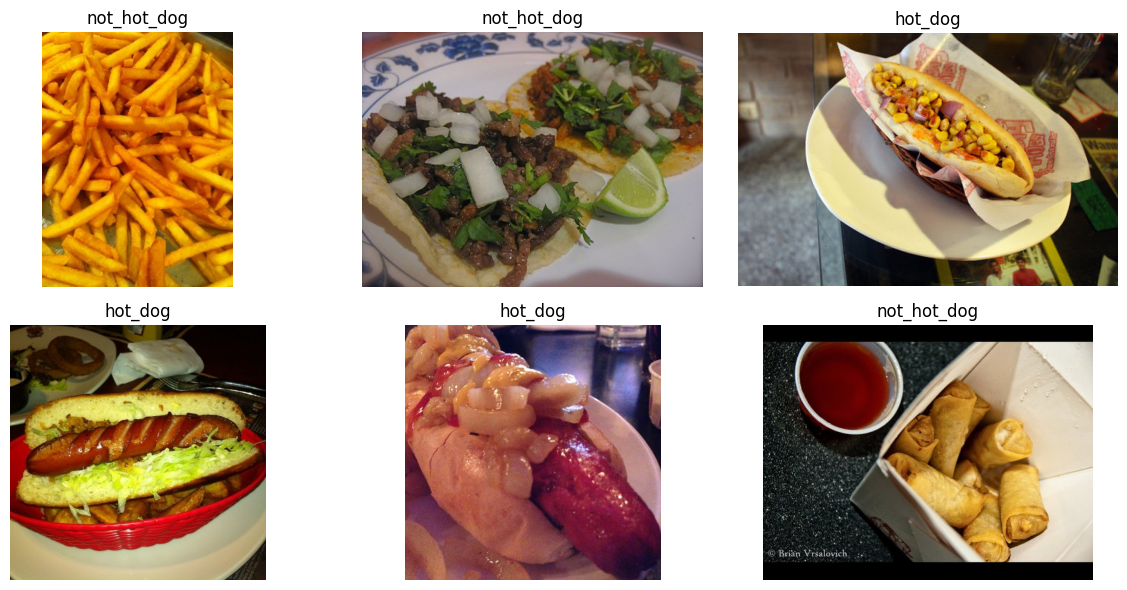

Image shape: (396, 512, 3)


In [8]:
plt.figure(figsize=(12, 6))

for i in range(6):
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name   = random.choice(os.listdir(class_path))
    img_path   = os.path.join(class_path, img_name)

    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print image shape
print("Image shape:", img.shape)

In [9]:
IMG_HEIGHT = 64
IMG_WIDTH  = 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Print class labels
print(train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
{'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.5200 - loss: 1.4231 - val_accuracy: 0.5000 - val_loss: 0.9785
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5450 - loss: 0.7877 - val_accuracy: 0.5000 - val_loss: 0.8270
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.6200 - loss: 0.6464 - val_accuracy: 0.5408 - val_loss: 0.8642
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.6050 - loss: 0.6662 - val_accuracy: 0.5714 - val_loss: 0.7102
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7075 - loss: 0.5724 - val_accuracy: 0.5408 - val_loss: 0.7667
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7450 - loss: 0.5287 - val_accuracy: 0.5306 - val_loss: 0.7655
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.7675 - loss: 0.4885 - val_accuracy: 0.5408 - val_loss: 0.7311
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.7725 - loss: 0.4799 - val_accuracy: 0.5612 -

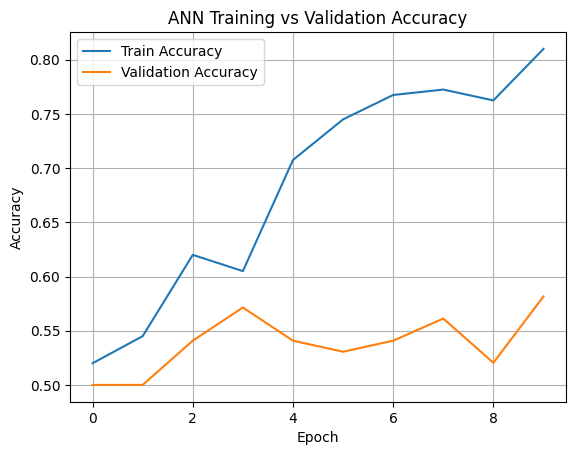

In [10]:
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot
plt.plot(history_ann.history['accuracy'],     label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ANN Training vs Validation Accuracy')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.4875 - loss: 0.6985 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.5225 - loss: 0.6908 - val_accuracy: 0.4898 - val_loss: 0.6894
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.6000 - loss: 0.6813 - val_accuracy: 0.5714 - val_loss: 0.6783
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.6400 - loss: 0.6482 - val_accuracy: 0.5816 - val_loss: 0.6868
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.6625 - loss: 0.6329 - val_accuracy: 0.6020 - val_loss: 0.6719
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.7050 - loss: 0.5881 - val_accuracy: 0.5714 - val_loss: 0.7385
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.7175 - loss: 0.5467 - val_accuracy: 0.6020 - val_loss: 0.7046
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.7725 - loss: 0.4948 - val_accuracy: 0.

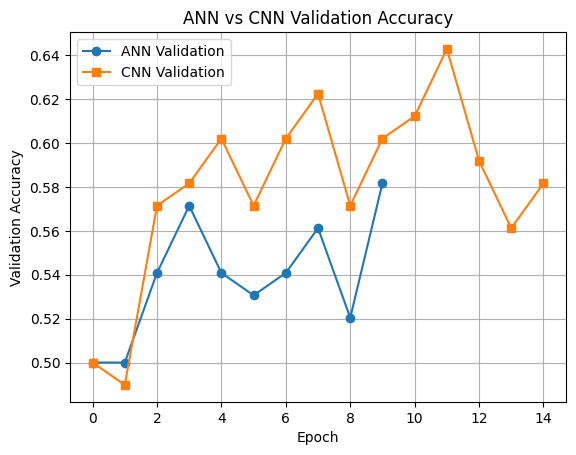

In [11]:
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

# ANN vs CNN plot
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 0.5075 - loss: 0.7203 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.4975 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step - accuracy: 0.5200 - loss: 0.6910 - val_accuracy: 0.4898 - val_loss: 0.6936
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.5175 - loss: 0.6905 - val_accuracy: 0.5204 - val_loss: 0.6925
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.5325 - loss: 0.6970 - val_accuracy: 0.5510 - val_loss: 0.6917
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.5475 - loss: 0.6893 - val_accuracy: 0.5510 - val_loss: 0.6897
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 364ms/step - accuracy: 0.5300 - loss: 0.6871 - val_accuracy: 0.5408 - val_loss: 0.6873
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 266ms/step - accuracy:

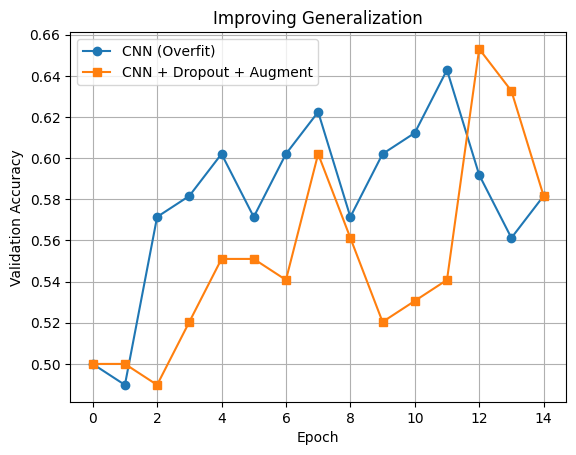

In [12]:
# Augmented data generator
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Final model with Dropout + Augmentation
final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)

# Before vs After plot
plt.plot(history_cnn.history['val_accuracy'],   label='CNN (Overfit)',           marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
HOT DOG! (confidence: 0.78)


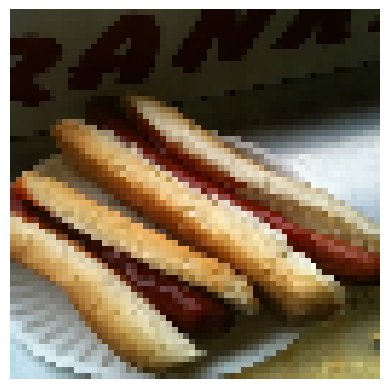

In [22]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_local_image(img_path):
    img       = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = final_model.predict(img_array)[0][0]

    if prediction > 0.5:
        print(f"HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"NOT A HOT DOG! (confidence: {1 - prediction:.2f})")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Use a test image directly from your dataset
predict_local_image("/content/seefood/test/hot_dog/292683.jpg")


image 1/1 /content/seefood/test/hot_dog/292683.jpg: 640x480 2 hot dogs, 182.2ms
Speed: 6.0ms preprocess, 182.2ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 480)


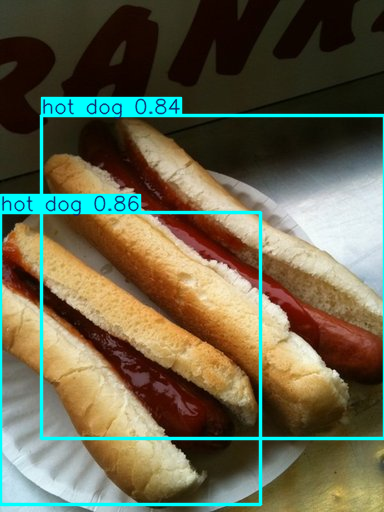

In [24]:
!pip install ultralytics -q

from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")

# Use local image instead of URL
results = yolo_model("/content/seefood/test/hot_dog/292683.jpg")

results[0].show()